In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
from pathlib import Path
import numpy as np

import mphsweepkit.process_derive as derive
from mphsweepkit.meta_tex import *
from mphsweepkit.process_data import DataPlot, PlotSettings, PlotTextOverrides
from mphsweepkit.process_fields import PlotField
from mphsweepkit.process_helpers import read_comsol_dataset

In [3]:
# 1) Load result data exported by CascadedSweepModel.save_result_data(...)
result_dir = Path("global_data")  # adjust if needed
dp = DataPlot.from_result_folder(result_dir)

# 2) Inspect loaded data
print("Input shape:", dp.input_df.shape)
print("Output shape:", dp.output_df.shape)
print("Combined shape:", dp.combined_df.shape)

print("\nInput columns:", dp.input_columns())
print("Output columns:", dp.output_columns())

# 3) Access metadata
y_col = dp.output_columns()[0]
print(f"\nSelected output column: {y_col}")
print("Label:", dp.get_label(y_col))
print("Unit:", dp.get_unit(y_col))
print("Axis label:", dp.format_axis_label(y_col))

# 4) Access combined dataframe
dp.combined_df.head()

Input shape: (77, 7)
Output shape: (77, 2)
Combined shape: (77, 9)

Input columns: ['height', 'length', 'width', 'matsw.comp1.sw1', 'voltage', 'core_temperature', 'freq']
Output columns: ['Z', 'C']

Selected output column: Z
Label: Z
Unit: Ohm
Axis label: Z [Ohm]


,height,length,width,matsw.comp1.sw1,voltage,core_temperature,freq,Z,C
name,,,,,,,,,
unit,mm,mm,mm,NaN,V,NaN,Hz,Ohm,F
group,Geometry Sweep,Geometry Sweep,Geometry Sweep,Material Sweep,Excitation Sweep,Excitation Sweep,Frequency Sweep,post-processing,post-processing
0,10.0,20.0,2.0,1.0,10.0,60.0,100000.0,(173.8873029981467-329.87864175559827j),(3.775568653838904e-09-1.9901969009160585e-09j)
1,10.0,20.0,2.0,1.0,10.0,60.0,200000.0,(86.57927674350127-202.07458680938336j),(3.327239426930338e-09-1.4255626483493754e-09j)
2,10.0,20.0,2.0,1.0,10.0,60.0,300000.0,(57.90119825838535-146.61602415263158j),(3.1302193166930873e-09-1.2361776299389637e-09j)


Exemplary Visualization of the impedance in dependence of the geometry with the **DataPlot** class

In [4]:
# There are some built-in functions for common derived data, 
# e.g. absolute value, phase, real and imaginary parts.
derive.abs(dp.combined_df, source_col="Z", new_col="Z_abs", unit="Ohm")
derive.phase_deg(dp.combined_df, source_col="Z", new_col="Z_phase")
derive.phase_rad(dp.combined_df, source_col="Z", new_col="Z_phase_rad")
derive.real(dp.combined_df, source_col="Z", new_col="Z_real", unit="Ohm")
derive.imag(dp.combined_df, source_col="Z", new_col="Z_imag", unit="Ohm")

# It is also possible to define your own derived data functions. 
# e.g. we can define a new column that is the square of the absolute value of an existing column:
derive.from_single_column(dp.combined_df, 
                       source_col="Z", 
                       new_col="|Z|^2", 
                       unit="Ohm^2", 
                       transform=lambda z: np.abs(z)**2)

# Also for derivations based on multiple columns, we can define a new column that is 
# the function of multiple existing columns. For example, we can define a new column that 
# is the volume of a cuboid based on the width, height and length columns:
derive.from_multiple_columns(
    dp.combined_df,
    source_cols=["width", "height", "length"],
    new_col="volume",
    unit="mm^3",
    func=lambda cols: cols[0] * cols[1] * cols[2],
    group="Derived",
)


dp.combined_df.head()

,height,length,width,matsw.comp1.sw1,voltage,core_temperature,freq,Z,C,Z_abs,Z_phase,Z_phase_rad,Z_real,Z_imag,|Z|^2,volume
name,,,,,,,,,,,,,,,,
unit,mm,mm,mm,NaN,V,NaN,Hz,Ohm,F,Ohm,deg,rad,Ohm,Ohm,Ohm^2,mm^3
group,Geometry Sweep,Geometry Sweep,Geometry Sweep,Material Sweep,Excitation Sweep,Excitation Sweep,Frequency Sweep,post-processing,post-processing,Derived,Derived,Derived,Derived,Derived,Derived,Derived
0,10.0,20.0,2.0,1.0,10.0,60.0,100000.0,(173.8873029981467-329.87864175559827j),(3.775568653838904e-09-1.9901969009160585e-09j),372.903087,-62.205161,-1.085685,173.887303,-329.878642,139056.71243,(400+0j)
1,10.0,20.0,2.0,1.0,10.0,60.0,200000.0,(86.57927674350127-202.07458680938336j),(3.327239426930338e-09-1.4255626483493754e-09j),219.841101,-66.807187,-1.166005,86.579277,-202.074587,48330.109796,(400+0j)
2,10.0,20.0,2.0,1.0,10.0,60.0,300000.0,(57.90119825838535-146.61602415263158j),(3.1302193166930873e-09-1.2361776299389637e-09j),157.635045,-68.450081,-1.194679,57.901198,-146.616024,24848.807298,(400+0j)


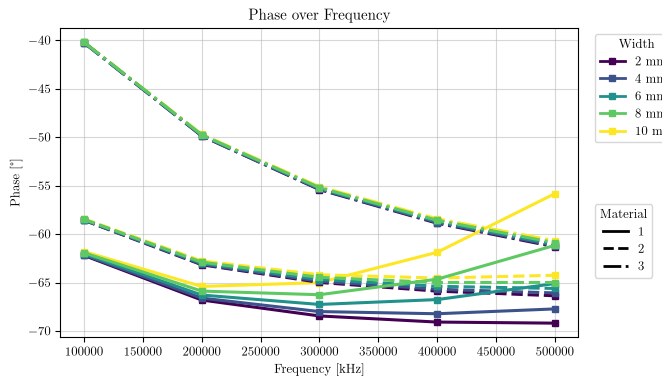

In [5]:
fig, ax = plt.subplots(figsize=(17 / 2.54, 10 / 2.54))  

custom_settings = PlotSettings(
    x_scale="linear",
    y_scale="linear",
    show_grid=True,
    grid_which="both",
    grid_alpha=0.5,
    marker="s",
    marker_size=5,
    line_width=2.2,
    color_map_name="viridis",
    line_styles=("-", "--", "-.", ":"),
    show_color_legend=True,
    show_style_legend=True,
    use_tight_layout=True
)

dp.y_over_x_with_color_and_style(
    ax,
    y_col="Z_phase",
    x_col="freq",
    color_col="width",
    style_col="matsw.comp1.sw1",
    settings=custom_settings,
    text_overrides=PlotTextOverrides(
        x_label="Frequency",
        x_unit="kHz",
        y_label="Phase",
        y_unit="°",
        color_label="Width",
        color_unit="mm",
        style_label="Material",
        style_unit=" ",
    ),
)

plt.show()

#### Field Plot
The goal is to plot a field based on the "global_idx" from the "combined_data"

In [11]:
# Read the exported text file into a pandas DataFrame and display the first few rows
geometry_no = 1
# TODO: add passing the parameter names as column names to the read_comsol_txt function

read_df = read_comsol_dataset(f"field_data/geometry_{geometry_no}.txt")
# read_df.head()

In [12]:
pf = PlotField(read_df)
# pf.df.head()

# TODO: build in analogy to the DataPlot -> PlotField can work with  just the directory of the result data,
#       and then read all the files in that directory to create a single PlotField object. 
#       This would allow for easier handling of multiple datasets without needing to manually read each file.
# result_dir = Path("result_data")  # adjust if needed
# dp = DataPlot.from_result_folder(result_dir)

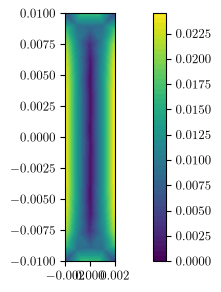

In [14]:
exemplary_column = pf.df.columns[9]

# Plot the data using tricontourf
pf.plot_field(
    x_col="x",
    y_col="y",
    value_col=exemplary_column,
    kind="tricontourf",
    levels=50,
    figsize=(8, 3)
)